# Mean-Variance with Forecasting (MVF) — LSTM + Classical Portfolio Optimization

**Hypothesis.** The Markowitz Mean-Variance (MV) model (1952) allocates assets to maximize
return for a given level of risk, but is *extremely sensitive to its inputs* — expected
returns, variances, and covariances. Traditionally these are estimated from **historical
averages**, which are noisy and backward-looking. Bad estimates → poorly-weighted portfolios
that under-perform out-of-sample, often beaten by a naive equal-weight (1/N) portfolio.

**Solution — MVF.** Replace the unreliable historical inputs with **LSTM forecasts**:

| Phase | What we do |
|-------|------------|
| **1. Forecast** | An LSTM is fed overlapping sequences of historical closing prices and learns non-linear, long-term dependencies. It outputs predicted future prices for each stock over the holding horizon. |
| **2. Predicted risk/return** | Use the predicted price *path* over the investment period to compute each stock's **expected return**, its **variance**, and the **covariance** between stocks — all forward-looking. |
| **3. Optimize** | Feed the predicted `μ` (returns) and `Σ` (covariance) into the classical MV optimizer. Search asset weights that **maximize the predicted Sharpe ratio** → the efficient-frontier / max-Sharpe (tangency) portfolio. |

We benchmark MVF against (a) **equal-weight (1/N)** and (b) **historical Mean-Variance**, then
walk the resulting weights forward on the held-out period to see realized performance.


In [79]:
# ── Libraries & path setup (same pattern as market_regime.ipynb) ─────────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.optimize import minimize

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', DEVICE)


torch 2.9.1 | device: cpu


In [80]:
# ── Load OHLCV via the project data loader ───────────────────────────────────
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'
df = load_stocks()
print(f'Shape : {df.shape}  |  {df.index[0].date()} → {df.index[-1].date()}')
df.close.tail()


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 985)  |  2016-07-04 → 2026-07-03
Shape : (2501, 985)  |  2016-07-04 → 2026-07-03


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-29,7.330,18.100,22.900,44.000,8.310,11.700,14.400,21.600,5.510,6.000,...,1854.970,56.100,12.200,27.050,2.590,61.900,28.200,18.750,63.000,9.300
2026-06-30,7.310,18.500,22.650,44.000,8.280,11.750,14.700,21.250,5.500,6.000,...,1860.010,54.800,12.250,27.000,2.590,62.000,28.500,19.000,63.400,9.520
2026-07-01,7.360,18.400,22.650,43.900,8.340,11.700,14.950,21.350,5.510,6.030,...,1867.210,55.200,12.450,27.700,2.600,62.100,28.300,18.900,65.500,9.430
2026-07-02,7.360,18.600,22.650,43.700,8.560,11.700,15.400,21.500,5.490,6.000,...,1866.350,55.500,12.350,27.700,2.600,61.700,28.150,18.800,65.000,9.320
2026-07-03,7.400,18.700,22.650,43.600,8.390,11.700,16.000,20.950,5.460,6.010,...,1862.080,54.900,12.250,27.800,2.570,61.500,28.150,18.650,63.900,9.220


## Configuration

A small, liquid universe keeps the per-asset LSTM training fast and the covariance matrix
well-conditioned. We rank watchlist names by median traded value (close × volume) and keep
the top `N_ASSETS`, excluding the benchmark/index.


In [ ]:
# ── Strategy configuration ───────────────────────────────────────────────────
N_ASSETS    = 12      # universe size (top liquid names)
SEQ_LEN     = 60      # LSTM look-back window (trading days)
HORIZON     = 21      # investment / holding period (≈ 1 month) we forecast forward
TRAIN_RATIO = 0.85    # chronological train fraction (rest is true out-of-sample)
RISK_FREE   = 0.0     # daily risk-free rate used in the Sharpe ratio
EPOCHS      = 40
LR          = 1e-3
BATCH       = 64

# ── MVF robustness knobs ─────────────────────────────────────────────────────
MAX_WEIGHT = 0.40    # per-asset cap in the max-Sharpe optimizer (0<..<=1; diversification)
COV_SHRINK = True    # Ledoit-Wolf shrink the (historical) covariance -> well-conditioned Σ

close = df.close.copy()

# universe selection by liquidity, excluding index/benchmark
INDEX_LIKE = {BENCHMARK, 'VN30', 'VNINDEX', 'HNXINDEX', 'UPINDEX'}
vol = df.volume.copy()
dollar_vol = (close * vol).median().drop(labels=[c for c in INDEX_LIKE if c in close.columns],
                                         errors='ignore')
# keep names with a full, clean history over the sample
clean = close.dropna(axis=1, how='any').columns
dollar_vol = dollar_vol[dollar_vol.index.isin(clean)]
UNIVERSE = list(dollar_vol.sort_values(ascending=False).head(N_ASSETS).index)

# adding custom universe
# UNIVERSE = ['DGW', 'VCG', 'PAN', 'BCM', 'GEX', 'VGC', 'MSN', 'PVS', 'VCI', 'HCM', 'PHR', 'GVR']
UNIVERSE = ['PET', 'VIC', 'VHM', 'ABB', 'MSB', 'LPB', 'HCM', 'SSB', 'GEX', 'VPI', 'GMD', 'NAB', 'DVM', 'STB', 'BSR', 'ACB', 'VCG', 'POW', 'VJC', 'PVD', 'HNG', 'SHS', 'MBS', 'VND']
prices = close[UNIVERSE].dropna()
print('Universe:', UNIVERSE)
print('Price panel:', prices.shape, '|', prices.index[0].date(), '→', prices.index[-1].date())

split_idx = int(len(prices) * TRAIN_RATIO)
split_date = prices.index[split_idx]
print(f'Train/test split @ {split_date.date()}  ({split_idx} / {len(prices)-split_idx} bars)')

Universe: ['DGW', 'VCG', 'PAN', 'BCM', 'GEX', 'VGC', 'MSN', 'PVS', 'VCI', 'HCM', 'PHR', 'GVR']
Price panel: (2501, 12) | 2016-07-04 → 2026-07-03
Train/test split @ 2024-12-26  (2125 / 376 bars)


## Phase 1 — Forecasting prices with an LSTM

For each asset we train an LSTM on **overlapping sequences** of two features — past
**log-returns** and the asset's **GKYZ volatility** (`gkyz_sym_norm`, the same OHLC-based
estimator used in `t_loser_autopsy.ipynb`) — over a `SEQ_LEN` window, to predict the next-day
log-return. Modelling returns keeps the target roughly stationary; the volatility channel gives
the model an explicit read on the current risk regime. After training, we **recursively roll the
model forward `HORIZON` steps** from the last observed window to generate a predicted price path.
The volatility feature is held at its last observed value across the horizon (no future OHLC to
recompute it).

In [82]:
# ── Build supervised sequences from log-returns + GKYZ volatility ────────────
log_ret = np.log(prices).diff().dropna()                     # (T-1, N)
ret_train = log_ret.iloc[:split_idx]
ret_test  = log_ret.iloc[split_idx:]

# standardise per-asset using TRAIN stats only (no leakage)
mu_r  = ret_train.mean()
sd_r  = ret_train.std().replace(0, 1e-8)
z_all = (log_ret - mu_r) / sd_r                              # standardised returns

# ── GKYZ volatility features (Garman-Klass-Yang-Zhang), as in t_loser_autopsy ─
# OHLC-based vol capturing intraday range + overnight gaps. We use the [0,1]
# rolling min-max NORMALISED value (`gkyz_sym_norm`). Two channels:
#   gkyz_sym : each asset's own volatility regime
#   gkyz_mkt : the market's (VNINDEX) volatility regime  — systemic risk context
# Both are computed on trailing data only (no look-ahead), so the walk-forward
# loop can slice them safely.
from backend.app.services.indicators.gkyz_volatility import gkyz_volatility_nb

GKYZ_WINDOW = 21
GKYZ_SYMS   = UNIVERSE + ([BENCHMARK] if BENCHMARK in df.close.columns else [])

def _ohlc(attr):
    return getattr(df, attr)[GKYZ_SYMS].reindex(prices.index).ffill().to_numpy(np.float64)

_g = gkyz_volatility_nb(_ohlc('close'), _ohlc('open'), _ohlc('high'), _ohlc('low'),
                        window=GKYZ_WINDOW, normalize=True)                       # [0,1]
gkyz_panel = (pd.DataFrame(_g, index=prices.index, columns=GKYZ_SYMS)
                .reindex(log_ret.index)          # align to the return series
                .ffill().fillna(0.0))            # fill warm-up NaNs
gkyz_sym = gkyz_panel[UNIVERSE]
gkyz_mkt = (gkyz_panel[BENCHMARK] if BENCHMARK in gkyz_panel.columns
            else pd.Series(0.0, index=log_ret.index))

# per-asset, per-time-step model input: [standardised return, own vol, market vol]
FEATURE_NAMES = ['ret_z', 'gkyz_sym', 'gkyz_mkt']
N_FEAT = len(FEATURE_NAMES)

def asset_feat(sym, z_series):
    """Stack per-asset features into a (T, N_FEAT) array aligned to z_series.index."""
    idx = z_series.index
    return np.column_stack([
        z_series.to_numpy(np.float32),
        gkyz_sym[sym].reindex(idx).to_numpy(np.float32),
        gkyz_mkt.reindex(idx).to_numpy(np.float32),
    ]).astype(np.float32)

def make_sequences(feat, tgt, seq_len):
    """feat: (T, F) feature matrix, tgt: (T,) next-step target (return).
    Returns X (n, seq_len, F) and y (n,)."""
    feat = np.asarray(feat, dtype=np.float32)
    tgt  = np.asarray(tgt,  dtype=np.float32)
    X, y = [], []
    for i in range(len(feat) - seq_len):
        X.append(feat[i:i+seq_len])
        y.append(tgt[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print('Standardised return matrix:', z_all.shape, '| features:', FEATURE_NAMES)
print('GKYZ panel:', gkyz_panel.shape, '| sym range:',
      round(float(gkyz_sym.min().min()), 3), '->', round(float(gkyz_sym.max().max()), 3),
      '| mkt range:', round(float(gkyz_mkt.min()), 3), '->', round(float(gkyz_mkt.max()), 3))

Standardised return matrix: (2500, 12) | features: ['ret_z', 'gkyz_sym', 'gkyz_mkt']
GKYZ panel: (2500, 13) | sym range: 0.0 -> 1.0 | mkt range: 0.0 -> 1.0


In [83]:
# ── LSTM model ───────────────────────────────────────────────────────────────
class PriceLSTM(nn.Module):
    def __init__(self, n_feat=N_FEAT, hidden=32, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):                 # x: (B, seq_len, n_feat)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)   # (B,)


def train_one_asset(feat, tgt, seq_len, split_idx, epochs=EPOCHS):
    # only train on sequences whose target falls inside the train window
    X, y = make_sequences(feat[:split_idx], tgt[:split_idx], seq_len)
    Xt = torch.tensor(X, device=DEVICE)
    yt = torch.tensor(y, device=DEVICE)
    dl = DataLoader(TensorDataset(Xt, yt), batch_size=BATCH, shuffle=True)

    model = PriceLSTM().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
    model.eval()
    return model

In [ ]:
# ── Train one LSTM per asset (with a per-symbol disk cache) ──────────────────
import hashlib, json

CACHE_DIR = ROOT / 'lstm_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False        # True -> ignore the cache and retrain everything
ARCH = dict(n_feat=N_FEAT, hidden=32, layers=2, dropout=0.2)   # must match PriceLSTM

def _fingerprint(sym, feat, tgt, seq_len, split_idx):
    """SHA over the TRAIN data + every knob that changes the fitted weights.
    Any change (universe, split, features, epochs, lr, batch, arch, seed, torch
    version) yields a new key, so a stale model is never silently reused."""
    h = hashlib.sha256()
    Xtr = np.ascontiguousarray(feat[:split_idx], dtype=np.float32)
    ytr = np.ascontiguousarray(np.asarray(tgt)[:split_idx], dtype=np.float32)
    h.update(sym.encode()); h.update(Xtr.tobytes()); h.update(ytr.tobytes())
    cfg = dict(seq_len=int(seq_len), split_idx=int(split_idx), epochs=EPOCHS,
               lr=LR, batch=BATCH, seed=SEED, feats=FEATURE_NAMES, arch=ARCH,
               torch=torch.__version__)
    h.update(json.dumps(cfg, sort_keys=True, default=str).encode())
    return h.hexdigest()[:16]

def train_one_asset_cached(sym, feat, tgt, seq_len, split_idx, use_cache=True):
    fp   = _fingerprint(sym, feat, tgt, seq_len, split_idx)
    path = CACHE_DIR / f'lstm_{sym}_{fp}.pt'
    if use_cache and path.exists():
        model = PriceLSTM(**ARCH).to(DEVICE)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.eval()
        return model, 'cached'
    # reseed per call so each asset's fit is reproducible regardless of cache hits
    torch.manual_seed(SEED)
    model = train_one_asset(feat, tgt, seq_len, split_idx)
    torch.save(model.state_dict(), path)
    return model, 'trained'


models = {}
for sym in UNIVERSE:
    feat = asset_feat(sym, z_all[sym])
    models[sym], src = train_one_asset_cached(
        sym, feat, z_all[sym].to_numpy(np.float32), SEQ_LEN, split_idx,
        use_cache=not FORCE_RETRAIN)
    print(f'  {src:>7} LSTM -> {sym}')
print('Done. Trained', len(models), 'models |', N_FEAT, 'features:', FEATURE_NAMES)
print('Cache dir:', CACHE_DIR)

  trained LSTM -> DGW
  trained LSTM -> VCG
  trained LSTM -> PAN
  trained LSTM -> BCM
  trained LSTM -> GEX
  trained LSTM -> VGC
  trained LSTM -> MSN
  trained LSTM -> PVS
  trained LSTM -> VCI
  trained LSTM -> HCM
  trained LSTM -> PHR
  trained LSTM -> GVR
Done. Trained 12 models | 3 features: ['ret_z', 'gkyz_sym', 'gkyz_mkt']


In [85]:
# ── Recursive multi-step forecast of the price path over HORIZON ─────────────
def forecast_path(model, feat_hist, seq_len, horizon, mu, sd, last_price):
    """Roll the model forward `horizon` days from the last `seq_len` feature window.
    Deterministic (eval mode) -> a stable point forecast. Non-return channels
    (GKYZ vol) are held at their last observed value (no future OHLC to recompute).
    Returns predicted *prices* (length horizon)."""
    window = [np.asarray(r, dtype=np.float32) for r in feat_hist[-seq_len:]]
    frozen = feat_hist[-1, 1:].astype(np.float32)        # hold vol channels constant
    preds_price, price = [], float(last_price)
    model.eval()
    with torch.no_grad():
        for _ in range(horizon):
            x = torch.tensor(np.array(window[-seq_len:], dtype=np.float32),
                             device=DEVICE).unsqueeze(0)      # (1, seq_len, N_FEAT)
            z_next = model(x).item()                          # standardised return
            price  = price * np.exp(z_next * sd + mu)         # de-standardise -> price
            preds_price.append(price)
            window.append(np.concatenate([[np.float32(z_next)], frozen]).astype(np.float32))
    return np.array(preds_price)

# forecast from the END OF TRAIN window (so the path overlaps the test period)
z_train_all      = z_all.iloc[:split_idx]
last_train_price = prices.iloc[split_idx-1]

pred_prices = pd.DataFrame(
    {sym: forecast_path(models[sym], asset_feat(sym, z_train_all[sym]), SEQ_LEN, HORIZON,
                        mu_r[sym], sd_r[sym], last_train_price[sym])
     for sym in UNIVERSE}
)
pred_prices.index = pd.RangeIndex(1, HORIZON+1, name='day_ahead')
print('Predicted price paths (head):')
pred_prices.head()

Predicted price paths (head):


,DGW,VCG,PAN,BCM,GEX,VGC,MSN,PVS,VCI,HCM,PHR,GVR
day_ahead,,,,,,,,,,,,
1,40.704,16.272,17.716,68.146,12.317,43.118,70.707,31.775,24.507,22.396,52.536,30.730
2,40.731,16.287,17.730,68.088,12.363,43.153,70.707,31.756,24.520,22.370,52.477,30.804
3,40.768,16.302,17.747,67.985,12.409,43.191,70.725,31.741,24.574,22.341,52.459,30.873
4,40.770,16.317,17.763,67.874,12.449,43.228,70.735,31.727,24.660,22.310,52.480,30.932
5,40.743,16.331,17.774,67.784,12.484,43.264,70.730,31.717,24.766,22.279,52.530,30.980


## Evaluation A — Stock-price prediction quality

Following the paper, we assess the LSTM forecasts with **both** error and direction metrics on
the held-out period, using **one-step-ahead** predictions (each `SEQ_LEN` window predicts the
next day's return — no recursion, so no compounding drift):

- **Regression:** Mean Squared Error (**MSE**) and Mean Absolute Error (**MAE**) in log-return space.
- **Classification (direction up/down):** **Accuracy, Precision, Recall, F1** on `sign(return)`.
- **Algorithm benchmarking:** the LSTM is compared against **Decision Tree, Random Forest,
  ANN (MLP), and SVM (SVR)** trained on the same flattened look-back windows.


In [86]:
# ── Prediction-eval harness (one-step-ahead, OOS) ────────────────────────────
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

def asset_xy(sym):
    # all (window -> next standardized return) pairs, split by target position
    X, y = make_sequences(asset_feat(sym, z_all[sym]), z_all[sym].to_numpy(np.float32), SEQ_LEN)
    tpos = np.arange(SEQ_LEN, SEQ_LEN + len(X))   # absolute index of each target
    tr = tpos < split_idx                         # same train region the LSTM saw
    return X[tr], y[tr], X[~tr], y[~tr]

def reg_class_metrics(actual_ret, pred_ret):
    a_dir = (actual_ret > 0).astype(int)
    p_dir = (pred_ret  > 0).astype(int)
    return {
        'MSE':       mean_squared_error(actual_ret, pred_ret),
        'MAE':       mean_absolute_error(actual_ret, pred_ret),
        'Accuracy':  accuracy_score(a_dir, p_dir),
        'Precision': precision_score(a_dir, p_dir, zero_division=0),
        'Recall':    recall_score(a_dir, p_dir, zero_division=0),
        'F1':        f1_score(a_dir, p_dir, zero_division=0),
    }

def evaluate(predict_fn):
    # predict_fn(sym, Xtr, ytr, Xte) -> standardized-return preds on the test window.
    # Returns (pooled_metrics, per_asset_DataFrame) in REAL log-return space.
    A, P, rows = [], [], {}
    for sym in UNIVERSE:
        Xtr, ytr, Xte, yte = asset_xy(sym)
        zhat = np.asarray(predict_fn(sym, Xtr, ytr, Xte)).ravel()
        sd, mu = sd_r[sym], mu_r[sym]
        a, p = yte * sd + mu, zhat * sd + mu       # de-standardize back to log-returns
        A.append(a); P.append(p)
        rows[sym] = reg_class_metrics(a, p)
    pooled = reg_class_metrics(np.concatenate(A), np.concatenate(P))
    return pooled, pd.DataFrame(rows).T

In [87]:
# ── LSTM one-step-ahead metrics (pooled + per-asset) ─────────────────────────
def lstm_predict(sym, Xtr, ytr, Xte):
    with torch.no_grad():
        xb = torch.tensor(Xte.astype(np.float32), device=DEVICE)
        return models[sym](xb).cpu().numpy()

lstm_pooled, lstm_per_asset = evaluate(lstm_predict)
print('LSTM pooled one-step-ahead OOS metrics:')
print(pd.Series(lstm_pooled).round(5))
print('\nPer-asset LSTM metrics:')
display(lstm_per_asset.round(4))


LSTM pooled one-step-ahead OOS metrics:
MSE         0.001
MAE         0.018
Accuracy    0.502
Precision   0.499
Recall      0.616
F1          0.551
dtype: float64

Per-asset LSTM metrics:


,MSE,MAE,Accuracy,Precision,Recall,F1
DGW,0.001,0.019,0.507,0.512,0.654,0.575
VCG,0.001,0.016,0.480,0.469,0.914,0.620
PAN,0.001,0.015,0.515,0.550,0.571,0.560
BCM,0.001,0.016,0.464,0.413,0.568,0.478
GEX,0.001,0.024,0.515,0.576,0.538,0.556
VGC,0.001,0.019,0.488,0.476,0.792,0.595
MSN,0.000,0.013,0.555,0.481,0.319,0.384
PVS,0.001,0.020,0.491,0.450,0.437,0.443
VCI,0.001,0.017,0.477,0.500,0.617,0.552
HCM,0.001,0.016,0.507,0.562,0.521,0.541


Algorithm benchmark (pooled across universe, one-step-ahead OOS):


,MSE,MAE,Accuracy,Precision,Recall,F1
Decision Tree,0.001,0.019,0.496,0.496,0.754,0.598
Random Forest,0.001,0.018,0.498,0.496,0.649,0.562
LSTM,0.001,0.018,0.502,0.499,0.616,0.551
SVM (SVR),0.001,0.018,0.514,0.511,0.549,0.529
ANN (MLP),0.001,0.026,0.502,0.500,0.500,0.500


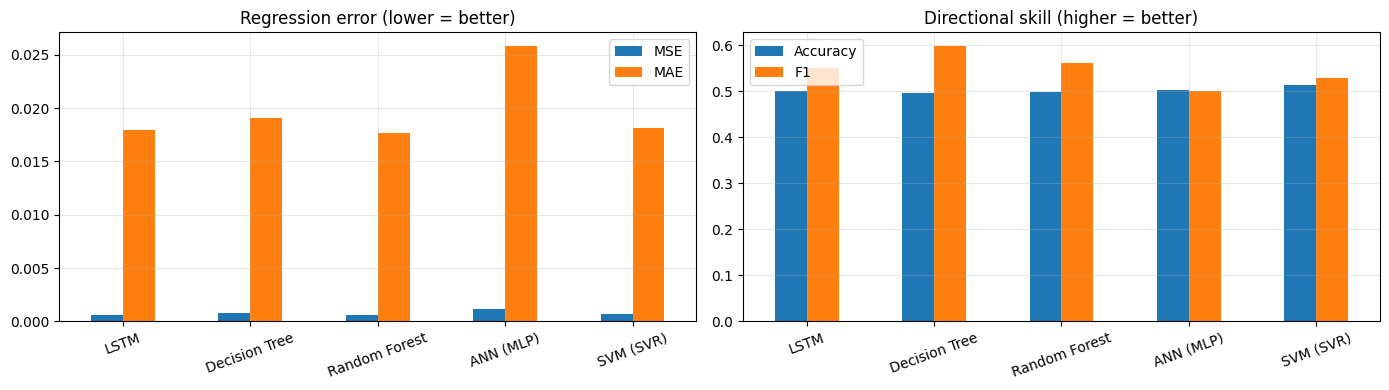

In [88]:
# ── Algorithm benchmark: LSTM vs Decision Tree / Random Forest / ANN / SVM ───
def sk_predict(factory):
    def f(sym, Xtr, ytr, Xte):
        m = factory()
        m.fit(Xtr.reshape(len(Xtr), -1), ytr)           # flatten (n, seq_len, F) -> (n, seq_len*F)
        return m.predict(Xte.reshape(len(Xte), -1))
    return f

ALGOS = {
    'LSTM':          lstm_predict,
    'Decision Tree': sk_predict(lambda: DecisionTreeRegressor(max_depth=8, random_state=SEED)),
    'Random Forest': sk_predict(lambda: RandomForestRegressor(n_estimators=100, max_depth=8,
                                                              n_jobs=-1, random_state=SEED)),
    'ANN (MLP)':     sk_predict(lambda: MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300,
                                                     random_state=SEED)),
    'SVM (SVR)':     sk_predict(lambda: SVR(C=1.0, kernel='rbf')),
}

bench_df = pd.DataFrame({name: evaluate(fn)[0] for name, fn in ALGOS.items()}).T
bench_df = bench_df[['MSE', 'MAE', 'Accuracy', 'Precision', 'Recall', 'F1']]
print('Algorithm benchmark (pooled across universe, one-step-ahead OOS):')
display(bench_df.round(5).sort_values('F1', ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bench_df[['MSE', 'MAE']].plot.bar(ax=ax[0], title='Regression error (lower = better)')
bench_df[['Accuracy', 'F1']].plot.bar(ax=ax[1], title='Directional skill (higher = better)')
for a in ax:
    a.grid(alpha=0.3); a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## Phase 2 — Predicted return & (shrunk) risk

We split the MV inputs by what each source estimates *reliably*:

- **Expected return `μ`** — **forward-looking**, from the LSTM: the total predicted return of
  each stock over the holding horizon (buy price → end of horizon), annualized. This is where
  the model's signal lives.
- **Covariance `Σ`** — from **historical daily returns**, **Ledoit-Wolf shrunk**. A single
  deterministic forecast path yields a degenerate, ill-conditioned covariance (it blows the
  optimizer up), and per-asset forecasts carry no reliable *cross-asset* correlation anyway.
  Historical returns give real, well-conditioned co-movement; shrinkage keeps `Σ` invertible.

So MVF = *predicted μ* + *shrunk historical Σ*; the Historical-MV baseline uses the *same Σ*
with *historical μ* — isolating the value of the LSTM return forecast.

In [89]:
# ── Predicted MV inputs (forecast μ, shrunk historical Σ) ────────────────────
from sklearn.covariance import LedoitWolf

ANN = 252

def shrunk_cov(daily_returns, ann=ANN):
    """Annualized covariance of daily returns; Ledoit-Wolf shrunk when COV_SHRINK."""
    cols = daily_returns.columns
    R = daily_returns.to_numpy(dtype=float)
    cov = LedoitWolf().fit(R).covariance_ if COV_SHRINK else np.cov(R, rowvar=False)
    return pd.DataFrame(cov * ann, index=cols, columns=cols)

# μ: forward-looking, from the LSTM price paths (annualized total horizon return)
total_ret = pred_prices.iloc[-1] / last_train_price[UNIVERSE] - 1.0
mu_pred   = (1 + total_ret) ** (ANN / HORIZON) - 1

# Σ: Ledoit-Wolf-shrunk HISTORICAL daily returns (real correlations, well-conditioned)
Sigma_pred = shrunk_cov(log_ret.iloc[:split_idx][UNIVERSE])

print('Predicted annualized expected returns (LSTM):')
print(mu_pred.sort_values(ascending=False).round(3))
print(f'\nΣ source: historical daily returns | shrinkage: {"Ledoit-Wolf" if COV_SHRINK else "none"}'
      f' | condition number: {np.linalg.cond(Sigma_pred.values):.1f}')

Predicted annualized expected returns (LSTM):
GEX    0.743
PHR    0.646
GVR    0.337
VCI    0.253
VCG    0.235
VGC    0.229
BCM    0.056
PAN    0.050
MSN    0.021
DGW   -0.031
PVS   -0.047
HCM   -0.235
dtype: float64

Σ source: historical daily returns | shrinkage: Ledoit-Wolf | condition number: 15.1


## Phase 3 — Mean-Variance optimization (maximize predicted Sharpe)

We solve the long-only, fully-invested max-Sharpe (tangency) problem:

$$\max_{w}\; \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma\, w}}\quad\text{s.t.}\quad \sum_i w_i = 1,\; w_i \ge 0$$

via SLSQP, and also trace the **efficient frontier** for context.


In [90]:
# ── Max-Sharpe optimizer (long-only, fully invested, per-asset cap) ──────────
def port_stats(w, mu, Sigma, rf=0.0):
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ Sigma @ w))
    sharpe = (ret - rf) / vol if vol > 0 else 0.0
    return ret, vol, sharpe

def max_sharpe(mu, Sigma, rf=0.0, w_max=1.0):
    n = len(mu)
    mu_v, S = mu.values, Sigma.values
    neg_sharpe = lambda w: -port_stats(w, mu_v, S, rf)[2]
    cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1},)
    w_max = max(w_max, 1.0 / n)                     # keep the problem feasible
    bnds = tuple((0.0, w_max) for _ in range(n))
    w0 = np.repeat(1/n, n)
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 1000, 'ftol': 1e-10})
    return pd.Series(res.x, index=mu.index)

RF_ANN = RISK_FREE * ANN
w_mvf = max_sharpe(mu_pred, Sigma_pred, RF_ANN, w_max=MAX_WEIGHT)
r, v, s = port_stats(w_mvf.values, mu_pred.values, Sigma_pred.values, RF_ANN)
print(f'MVF (LSTM) max-Sharpe weights  (cap = {MAX_WEIGHT:.0%}):')
print(w_mvf[w_mvf > 1e-4].sort_values(ascending=False).round(3))
print(f'\nPredicted  return={r:.2%}  vol={v:.2%}  Sharpe={s:.2f}')

MVF (LSTM) max-Sharpe weights  (cap = 40%):
PHR   0.400
GEX   0.400
GVR   0.097
VCG   0.091
BCM   0.008
VCI   0.004
dtype: float64

Predicted  return=61.14%  vol=30.68%  Sharpe=1.99


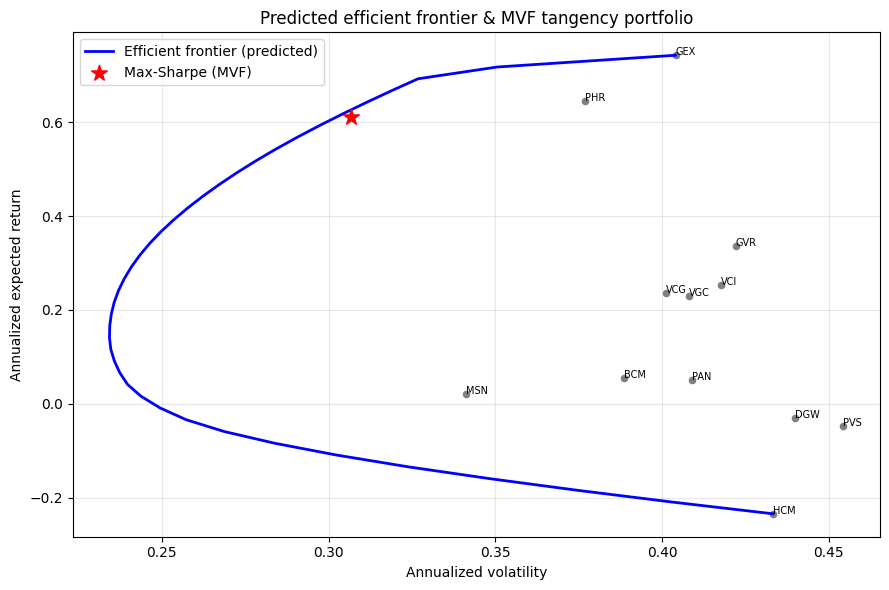

In [91]:
# ── Efficient frontier (predicted inputs) ────────────────────────────────────
def min_vol_for_target(mu, Sigma, target):
    n = len(mu); S = Sigma.values
    obj = lambda w: float(w @ S @ w)
    cons = ({'type':'eq','fun': lambda w: w.sum()-1},
            {'type':'eq','fun': lambda w: float(w @ mu.values) - target})
    bnds = tuple((0,1) for _ in range(n))
    res = minimize(obj, np.repeat(1/n,n), method='SLSQP', bounds=bnds,
                   constraints=cons, options={'maxiter':1000,'ftol':1e-10})
    return np.sqrt(res.fun) if res.success else np.nan

targets = np.linspace(mu_pred.min(), mu_pred.max(), 40)
front_vol = [min_vol_for_target(mu_pred, Sigma_pred, t) for t in targets]

plt.figure(figsize=(9,6))
plt.plot(front_vol, targets, 'b-', lw=2, label='Efficient frontier (predicted)')
plt.scatter(v, r, c='red', s=140, marker='*', zorder=5, label='Max-Sharpe (MVF)')
for sym in UNIVERSE:
    plt.scatter(np.sqrt(Sigma_pred.loc[sym,sym]), mu_pred[sym], c='gray', s=20)
    plt.annotate(sym, (np.sqrt(Sigma_pred.loc[sym,sym]), mu_pred[sym]), fontsize=7)
plt.xlabel('Annualized volatility'); plt.ylabel('Annualized expected return')
plt.title('Predicted efficient frontier & MVF tangency portfolio')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Baselines & out-of-sample backtest

To test the hypothesis we compare three weight schemes on the **held-out** period
(`split_date` → end), all bought at the split date and held:

1. **MVF** — max-Sharpe on LSTM-predicted `μ, Σ`.
2. **Equal-weight (1/N)** — the naive benchmark that famously beats badly-estimated MV.
3. **Historical MV** — max-Sharpe on `μ, Σ` estimated from *trailing historical* returns
   (the classical approach MVF aims to improve on).


In [105]:
# ── Build the three portfolios ───────────────────────────────────────────────
# historical inputs from the train window
hist_daily = log_ret.iloc[:split_idx][UNIVERSE]
mu_hist    = hist_daily.mean() * ANN
Sigma_hist = shrunk_cov(hist_daily)                    # same shrunk Σ as MVF -> isolates μ

w_eq   = pd.Series(np.repeat(1/len(UNIVERSE), len(UNIVERSE)), index=UNIVERSE)
w_hist = max_sharpe(mu_hist, Sigma_hist, RF_ANN, w_max=MAX_WEIGHT)

weights = {'MVF (LSTM)': w_mvf, 'Equal-weight': w_eq, 'Historical MV': w_hist}

# realized OOS daily simple returns
oos_prices = prices.iloc[split_idx-1:]                 # include split-1 as buy price
oos_ret = oos_prices.pct_change().dropna()[UNIVERSE]

results = {}
for name, w in weights.items():
    port_ret = oos_ret @ w.reindex(UNIVERSE).fillna(0).values
    equity = (1 + port_ret).cumprod()
    ann_ret = (1 + port_ret).prod() ** (ANN/len(port_ret)) - 1
    ann_vol = port_ret.std() * np.sqrt(ANN)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    dd = (equity / equity.cummax() - 1).min()
    results[name] = dict(equity=equity, ann_ret=ann_ret, ann_vol=ann_vol,
                         sharpe=sharpe, max_dd=dd)

summary = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'equity'}
                        for k, v in results.items()}).T
summary[['ann_ret','ann_vol','sharpe','max_dd']].round(3)

,ann_ret,ann_vol,sharpe,max_dd
MVF (LSTM),0.430,0.330,1.306,-0.243
Equal-weight,0.157,0.260,0.602,-0.255
Historical MV,0.064,0.309,0.206,-0.303


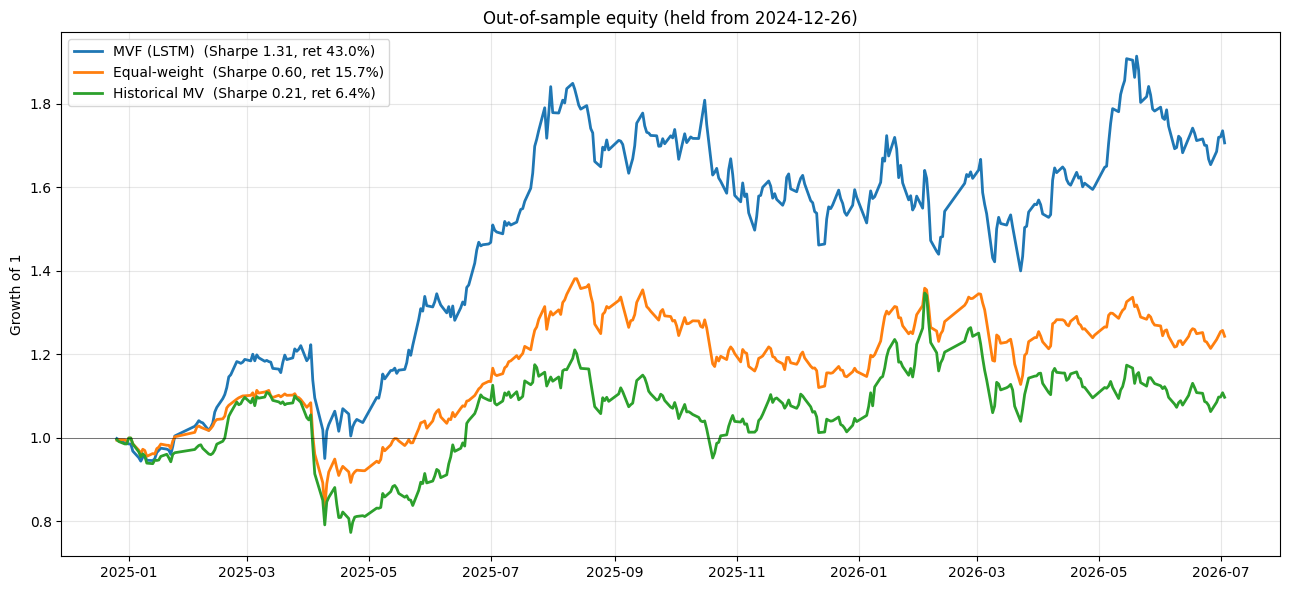

In [93]:
# ── Plot realized out-of-sample equity curves ────────────────────────────────
plt.figure(figsize=(13,6))
for name, r in results.items():
    plt.plot(r['equity'].index, r['equity'].values, lw=2,
             label=f"{name}  (Sharpe {r['sharpe']:.2f}, ret {r['ann_ret']:.1%})")
plt.axhline(1.0, color='k', lw=0.7, alpha=0.5)
plt.title(f'Out-of-sample equity (held from {split_date.date()})')
plt.ylabel('Growth of 1'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Evaluation B — Portfolio performance & market benchmarking

The portfolios are judged on **Expected Return, Volatility, and Sharpe ratio**, then validated
on **real** out-of-sample returns. We benchmark LSTM+MVF against two passive baselines, mirroring
the paper's EURO STOXX 50 + (LSTM + 1/N) comparison:

- **Market index** — the Vietnam analogue of the EURO STOXX 50 is **VNINDEX**. Does the active,
  predictive strategy beat simply holding the market?
- **Equal-weight (LSTM + 1/N)** — already computed above; does the mean-variance optimization add
  tangible value over naively splitting the budget evenly?


Portfolio evaluation (out-of-sample):


,ann_ret,ann_vol,sharpe,max_dd,excess_vs_VNINDEX,beats_VNINDEX
MVF (LSTM),0.430,0.330,1.306,-0.243,0.141,True
Equal-weight,0.157,0.260,0.602,-0.255,-0.133,False
Historical MV,0.064,0.309,0.206,-0.303,-0.226,False
VNINDEX,0.290,0.209,1.383,-0.181,0.000,False


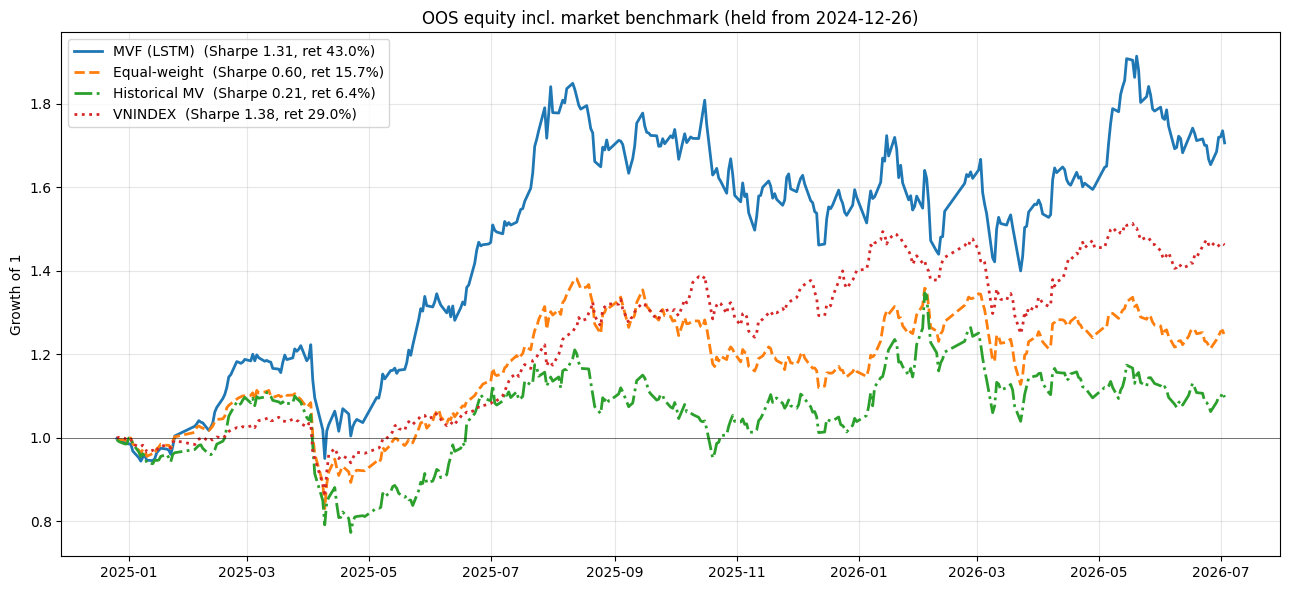

In [104]:
# ── Add the market benchmark (VNINDEX) and finalize the comparison ───────────
bench_close  = df.close[BENCHMARK].reindex(oos_prices.index).ffill()
bench_ret    = bench_close.pct_change().reindex(oos_ret.index).fillna(0)
bench_equity = (1 + bench_ret).cumprod()
b_ann_ret = (1 + bench_ret).prod() ** (ANN / len(bench_ret)) - 1
b_ann_vol = bench_ret.std() * np.sqrt(ANN)
results[BENCHMARK] = dict(
    equity=bench_equity, ann_ret=b_ann_ret, ann_vol=b_ann_vol,
    sharpe=(b_ann_ret / b_ann_vol if b_ann_vol > 0 else 0),
    max_dd=(bench_equity / bench_equity.cummax() - 1).min())

final = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'equity'}
                      for k, v in results.items()}).T
final = final[['ann_ret', 'ann_vol', 'sharpe', 'max_dd']].astype(float)
final['excess_vs_' + BENCHMARK] = final['ann_ret'] - final.loc[BENCHMARK, 'ann_ret']
final['beats_' + BENCHMARK] = final['excess_vs_' + BENCHMARK] > 0
print('Portfolio evaluation (out-of-sample):')
display(final.round(3))

plt.figure(figsize=(13, 6))
styles = {'MVF (LSTM)': '-', 'Equal-weight': '--', 'Historical MV': '-.', BENCHMARK: ':'}
for name, r in results.items():
    plt.plot(r['equity'].index, r['equity'].values, styles.get(name, '-'), lw=2,
             label=f"{name}  (Sharpe {r['sharpe']:.2f}, ret {r['ann_ret']:.1%})")
plt.axhline(1.0, color='k', lw=0.7, alpha=0.5)
plt.title(f'OOS equity incl. market benchmark (held from {split_date.date()})')
plt.ylabel('Growth of 1'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### Notes & next steps

- **Forecast horizon vs. backtest length.** The LSTM forecasts a single `HORIZON`-day path
  once (at the split). For a robust study, **roll** the whole pipeline forward — refit/forecast
  and re-optimize each month — to get many out-of-sample holding periods instead of one.
- **Recursive forecasting drifts.** Multi-step recursion compounds error; consider a
  seq2seq / direct multi-horizon head, or quantile outputs, to get a richer predicted
  return *distribution* for `Σ` rather than a single deterministic path.
- **Regularize Σ.** Predicted covariance from one path can be ill-conditioned; Ledoit-Wolf
  shrinkage or a longer simulated ensemble (MC dropout) stabilizes the optimizer.
- **Regime awareness.** Feed the regime labels from `market_regime.ipynb` as an extra LSTM
  input feature, or switch covariance estimates by regime.


## Evaluation C — Rolling (walk-forward) backtest

The single-shot test above forecasts and optimizes **once** at the split, giving just one holding
period — too thin to trust the Sharpe comparison. Here we **walk forward**: at each rebalance date
we forecast the next `HORIZON` days, re-solve the max-Sharpe weights, hold them for `HORIZON` days,
then roll on. Tail rebalances near the dataset end realize a **partial hold** for whatever days
remain. Stitching the non-overlapping holding periods yields many out-of-sample observations.

**Config:**
- `WF_RETRAIN_EVERY` — `0` reuses the models trained once on the initial window (fast, fixed model);
  `N` retrains all assets every `N` rebalances on an expanding window (slower, adapts to drift).
- `WF_EPOCHS` — epochs per retrain in the loop (kept lower than the initial fit for speed).

Standardization uses **train-only** statistics as of each rebalance, so there is no look-ahead.


In [106]:
# ── Walk-forward configuration & universe-fitter ─────────────────────────────
WF_RETRAIN_EVERY = 0     # 0/None -> train once & reuse; N -> retrain every N rebalances
WF_EPOCHS        = 20    # epochs per (re)train inside the loop
WF_HIST_LOOKBACK = 252   # trailing window for the Historical-MV baseline

def fit_universe(end_pos, epochs):
    # (Re)train one LSTM per asset on [return, GKYZ] features up to `end_pos` (exclusive).
    # Standardization uses ONLY data before end_pos -> no leakage. Returns (models, mu, sd, z).
    rt = log_ret.iloc[:end_pos]
    mu = rt.mean()
    sd = rt.std().replace(0, 1e-8)
    z  = (log_ret - mu) / sd
    mdl = {}
    for sym in UNIVERSE:
        feat = asset_feat(sym, z[sym].iloc[:end_pos])
        X, y = make_sequences(feat, z[sym].to_numpy(np.float32)[:end_pos], SEQ_LEN)
        dl = DataLoader(TensorDataset(torch.tensor(X, device=DEVICE),
                                      torch.tensor(y, device=DEVICE)),
                        batch_size=BATCH, shuffle=True)
        m = PriceLSTM().to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=LR)
        loss_fn = nn.MSELoss()
        m.train()
        for _ in range(epochs):
            for xb, yb in dl:
                opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
        m.eval(); mdl[sym] = m
    return mdl, mu, sd, z

In [107]:
# ── Walk-forward loop ────────────────────────────────────────────────────────
# positions are indices into the return series `log_ret` (z.index[b] == prices date)
n_ret      = len(log_ret)
start_pos  = max(split_idx, SEQ_LEN + 1)
rebal_pos  = list(range(start_pos, n_ret, HORIZON))
# if the last bar is off the HORIZON grid, still emit forward-looking weights for it
if rebal_pos and rebal_pos[-1] != n_ret - 1:
    rebal_pos.append(n_ret - 1)
print(f'{len(rebal_pos)} rebalances | {log_ret.index[rebal_pos[0]].date()} '
      f'-> {log_ret.index[rebal_pos[-1]].date()} | retrain_every={WF_RETRAIN_EVERY} '
      f'| w_cap={MAX_WEIGHT:.0%}')

# benchmark daily simple returns (BENCHMARK is NOT in `log_ret`, which is UNIVERSE-only)
bench_close = df.close[BENCHMARK].reindex(prices.index).ffill()
bench_dret  = bench_close.pct_change().reindex(log_ret.index)

# strategies -> list of daily realized return Series (one per holding period)
strat_ret = {'MVF (LSTM)': [], 'Equal-weight': [], 'Historical MV': [], BENCHMARK: []}
wf_weights = {'MVF (LSTM)': [], 'Historical MV': []}

mdl = mu = sd = z = None
for step, b in enumerate(rebal_pos):
    # (re)train or reuse
    if mdl is None or (WF_RETRAIN_EVERY and step % WF_RETRAIN_EVERY == 0):
        mdl, mu, sd, z = fit_universe(b + 1, WF_EPOCHS)

    buy_date   = log_ret.index[b]                       # last observed return date == buy date
    last_price = prices.loc[buy_date]

    # --- μ: deterministic LSTM forecast over the horizon ---
    pp = pd.DataFrame({sym: forecast_path(mdl[sym], asset_feat(sym, z[sym].iloc[:b+1]),
                                          SEQ_LEN, HORIZON, mu[sym], sd[sym], last_price[sym])
                       for sym in UNIVERSE})
    total = pp.iloc[-1] / last_price[UNIVERSE] - 1.0
    mu_p  = (1 + total) ** (ANN / HORIZON) - 1

    # --- Σ: shrunk historical covariance (shared by MVF and the baseline) ---
    hist = log_ret.iloc[max(0, b + 1 - WF_HIST_LOOKBACK):b + 1][UNIVERSE]
    Sig  = shrunk_cov(hist)
    mu_h = hist.mean() * ANN

    w_mvf_t  = max_sharpe(mu_p, Sig, RF_ANN, w_max=MAX_WEIGHT)
    w_hist_t = max_sharpe(mu_h, Sig, RF_ANN, w_max=MAX_WEIGHT)
    w_eq_t   = pd.Series(np.repeat(1/len(UNIVERSE), len(UNIVERSE)), index=UNIVERSE)
    wf_weights['MVF (LSTM)'].append(w_mvf_t.rename(buy_date))
    wf_weights['Historical MV'].append(w_hist_t.rename(buy_date))

    # --- realized daily returns over the holding period (up to HORIZON days) ---
    hold_dates = log_ret.index[b + 1 : min(b + 1 + HORIZON, n_ret)]
    if len(hold_dates) == 0:            # buy on the last bar: weights only, nothing to realize
        continue
    hold_ret   = log_ret.loc[hold_dates, UNIVERSE]          # log-returns; ~simple for daily
    realized   = (np.exp(hold_ret) - 1.0)                  # convert to simple returns
    strat_ret['MVF (LSTM)'].append(realized @ w_mvf_t.values)
    strat_ret['Historical MV'].append(realized @ w_hist_t.values)
    strat_ret['Equal-weight'].append(realized @ w_eq_t.values)
    strat_ret[BENCHMARK].append(bench_dret.reindex(hold_dates).fillna(0.0))

print('Walk-forward complete.')

19 rebalances | 2024-12-27 -> 2026-07-03 | retrain_every=0 | w_cap=40%
Walk-forward complete.


Walk-forward out-of-sample performance:


,ann_ret,ann_vol,sharpe,max_dd,hit_rate,n_days,excess_vs_VNINDEX
MVF (LSTM),0.267,0.287,0.932,-0.254,0.535,374.000,-0.023
Equal-weight,0.162,0.261,0.619,-0.255,0.551,374.000,-0.129
Historical MV,0.013,0.332,0.040,-0.431,0.513,374.000,-0.277
VNINDEX,0.291,0.210,1.384,-0.181,0.570,374.000,0.000


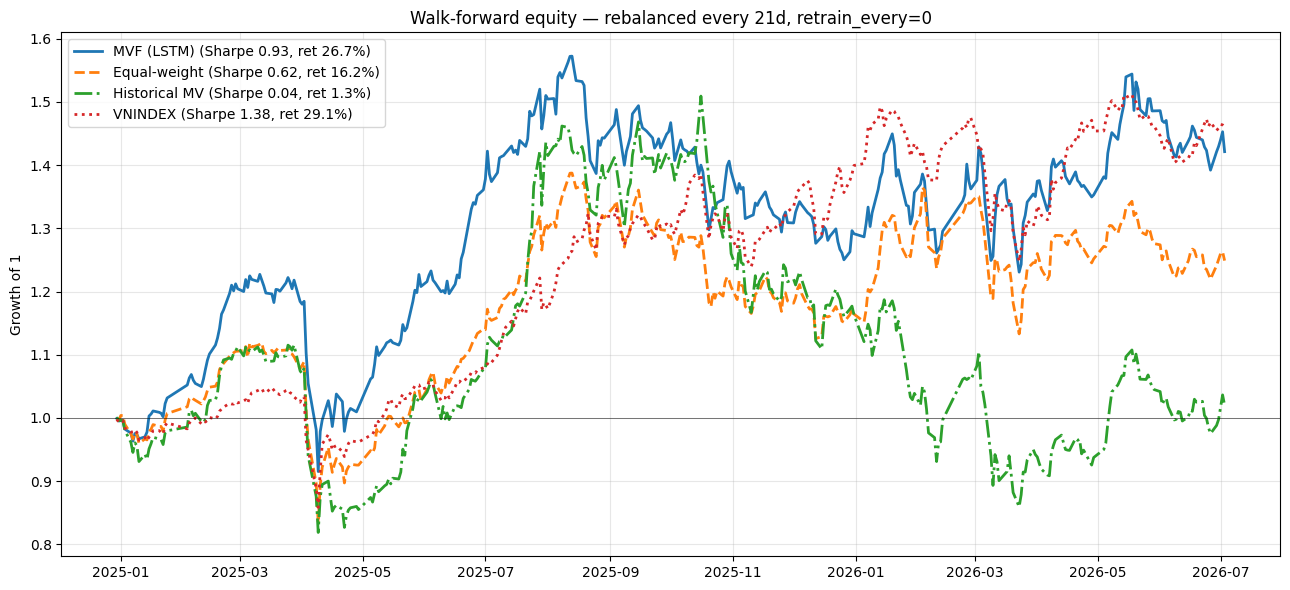

In [108]:
# ── Stitch holding periods, score, and plot ──────────────────────────────────
def summarize(daily):
    daily = daily.sort_index()
    eq = (1 + daily).cumprod()
    ann_ret = (1 + daily).prod() ** (ANN / len(daily)) - 1
    ann_vol = daily.std() * np.sqrt(ANN)
    sharpe  = (ann_ret - RF_ANN) / ann_vol if ann_vol > 0 else 0.0
    dd = (eq / eq.cummax() - 1).min()
    return eq, dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=sharpe, max_dd=dd,
                    hit_rate=(daily > 0).mean(), n_days=len(daily))

wf_eq, wf_stats = {}, {}
for name, chunks in strat_ret.items():
    daily = pd.concat(chunks)
    wf_eq[name], wf_stats[name] = summarize(daily)

wf_summary = pd.DataFrame(wf_stats).T[['ann_ret','ann_vol','sharpe','max_dd','hit_rate','n_days']]
wf_summary['excess_vs_'+BENCHMARK] = wf_summary['ann_ret'] - wf_summary.loc[BENCHMARK,'ann_ret']
print('Walk-forward out-of-sample performance:')
display(wf_summary.round(3))

plt.figure(figsize=(13,6))
styles = {'MVF (LSTM)':'-','Equal-weight':'--','Historical MV':'-.',BENCHMARK:':'}
for name, eq in wf_eq.items():
    plt.plot(eq.index, eq.values, styles.get(name,'-'), lw=2,
             label=f"{name} (Sharpe {wf_stats[name]['sharpe']:.2f}, ret {wf_stats[name]['ann_ret']:.1%})")
plt.axhline(1.0, color='k', lw=0.7, alpha=0.5)
plt.title(f'Walk-forward equity — rebalanced every {HORIZON}d, retrain_every={WF_RETRAIN_EVERY}')
plt.ylabel('Growth of 1'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


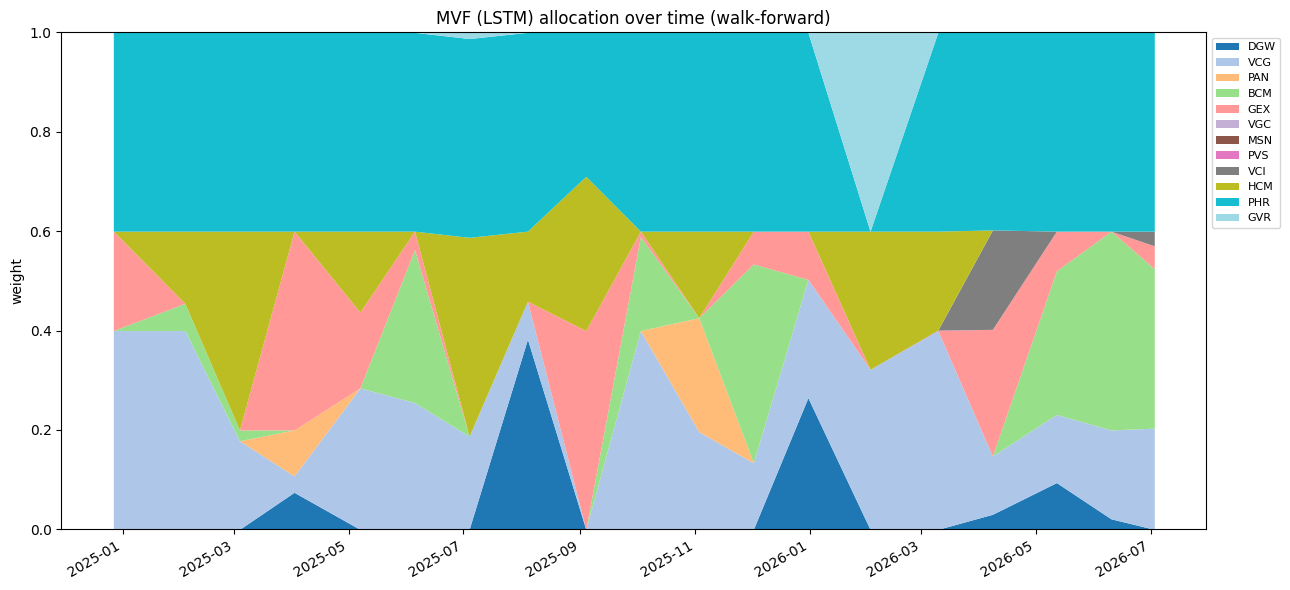

Average MVF turnover per rebalance: 0.782
Current MVF weights:


DGW   0.000
VCG   0.204
PAN   0.000
BCM   0.321
GEX   0.046
VGC   0.000
MSN   0.000
PVS   0.000
VCI   0.029
HCM   0.000
PHR   0.400
GVR   0.000
Name: 2026-07-03 00:00:00, dtype: float64

In [109]:
# ── MVF weight evolution across rebalances ───────────────────────────────────
W = pd.DataFrame(wf_weights['MVF (LSTM)']).fillna(0.0)
ax = W.plot.area(figsize=(13,6), cmap='tab20', linewidth=0)
ax.set_title('MVF (LSTM) allocation over time (walk-forward)')
ax.set_ylabel('weight'); ax.set_ylim(0, 1)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8, ncol=1)
plt.tight_layout(); plt.show()
print('Average MVF turnover per rebalance:',
      round(W.diff().abs().sum(axis=1).mean(), 3))
print('Current MVF weights:')
display(W.iloc[-1].round(3))


In [110]:
# ── Print MVF weights at every rebalance date ────────────────────────────────
# W is indexed by the rebalance (buy) date, columns = tickers, values = weights.
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print(f'MVF (LSTM) weights across {len(W)} rebalances\n' + '=' * 60)
for date, w in W.iterrows():
    nz = w[w > 1e-4].sort_values(ascending=False)
    alloc = '  '.join(f'{sym} {wt:.1%}' for sym, wt in nz.items())
    print(f'{date.date()} | {alloc}')

print('\nFull weight matrix (rebalance date × ticker):')
display(W.round(3))


MVF (LSTM) weights across 19 rebalances
2024-12-27 | VCG 40.0%  PHR 40.0%  GEX 20.0%
2025-02-03 | VCG 40.0%  PHR 40.0%  HCM 14.5%  BCM 5.5%
2025-03-04 | HCM 40.0%  PHR 40.0%  VCG 17.8%  BCM 2.2%
2025-04-02 | PHR 40.0%  GEX 40.0%  PAN 9.2%  DGW 7.5%  VCG 3.3%
2025-05-07 | PHR 40.0%  VCG 28.5%  HCM 16.3%  GEX 15.3%
2025-06-05 | PHR 40.0%  BCM 30.8%  VCG 25.5%  GEX 3.7%
2025-07-04 | PHR 40.0%  HCM 40.0%  VCG 18.8%  GVR 1.2%
2025-08-04 | PHR 40.0%  DGW 38.3%  HCM 14.1%  VCG 7.6%
2025-09-04 | GEX 40.0%  HCM 31.0%  PHR 29.0%
2025-10-03 | VCG 40.0%  PHR 40.0%  BCM 18.9%  GEX 1.1%
2025-11-03 | PHR 40.0%  PAN 22.9%  VCG 19.7%  HCM 17.4%
2025-12-02 | BCM 40.0%  PHR 40.0%  VCG 13.4%  GEX 6.6%
2025-12-31 | PHR 40.0%  DGW 26.5%  VCG 23.8%  GEX 9.7%
2026-02-02 | GVR 40.0%  VCG 32.2%  HCM 27.8%
2026-03-10 | VCG 40.0%  PHR 40.0%  HCM 19.9%  PVS 0.1%
2026-04-08 | PHR 39.8%  GEX 25.5%  VCI 20.0%  VCG 11.7%  DGW 3.0%
2026-05-12 | PHR 40.0%  BCM 28.9%  VCG 13.7%  DGW 9.4%  GEX 8.0%
2026-06-10 | PHR 40.0% 

,DGW,VCG,PAN,BCM,GEX,VGC,MSN,PVS,VCI,HCM,PHR,GVR
2024-12-27,0.000,0.400,0.000,0.000,0.200,0.000,0.000,0.000,0.000,0.000,0.400,0.000
2025-02-03,0.000,0.400,0.000,0.055,0.000,0.000,0.000,0.000,0.000,0.145,0.400,0.000
2025-03-04,0.000,0.178,0.000,0.022,0.000,0.000,0.000,0.000,0.000,0.400,0.400,0.000
2025-04-02,0.075,0.033,0.092,0.000,0.400,0.000,0.000,0.000,0.000,0.000,0.400,0.000
2025-05-07,0.000,0.285,0.000,0.000,0.153,0.000,0.000,0.000,0.000,0.163,0.400,0.000
2025-06-05,0.000,0.255,0.000,0.308,0.037,0.000,0.000,0.000,0.000,0.000,0.400,0.000
2025-07-04,0.000,0.188,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.400,0.400,0.012
2025-08-04,0.383,0.076,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.141,0.400,0.000
2025-09-04,0.000,0.000,0.000,0.000,0.400,0.000,0.000,0.000,0.000,0.310,0.290,0.000
2025-10-03,0.000,0.400,0.000,0.189,0.011,0.000,0.000,0.000,0.000,0.000,0.400,0.000


## Phase 4 — Final model & deployable weights

The walk-forward above *validates* the method out-of-sample. To actually trade, we now fit the
**production model on the entire dataset** (no hold-out — we want every last observation), forecast
the next `HORIZON` days from today, and solve the capped max-Sharpe portfolio. This is the
allocation you would put on **as of the last bar**.

Same recipe as the validated walk-forward: **μ** from the deterministic LSTM forecast, **Σ** from
the Ledoit-Wolf-shrunk trailing historical returns, long-only / fully-invested with a per-asset cap.

In [100]:
# ── Phase 4: train on ALL data, produce the final deployable weights ─────────
FINAL_EPOCHS = EPOCHS      # full training budget for the production model

# 1) (re)train one LSTM per asset on the ENTIRE history (no hold-out)
final_mdl, final_mu, final_sd, final_z = fit_universe(len(log_ret), FINAL_EPOCHS)

# 2) forecast the next HORIZON days from the most recent window (today)
as_of      = log_ret.index[-1]
last_price = prices.iloc[-1]
final_paths = pd.DataFrame(
    {sym: forecast_path(final_mdl[sym], asset_feat(sym, final_z[sym]), SEQ_LEN, HORIZON,
                        final_mu[sym], final_sd[sym], last_price[sym])
     for sym in UNIVERSE}
)

# 3) predicted μ (forecast) + shrunk historical Σ (trailing window, same as walk-forward)
total   = final_paths.iloc[-1] / last_price[UNIVERSE] - 1.0
mu_fin  = (1 + total) ** (ANN / HORIZON) - 1
Sig_fin = shrunk_cov(log_ret.iloc[-WF_HIST_LOOKBACK:][UNIVERSE])

# 4) max-Sharpe weights with the per-asset cap
w_final = max_sharpe(mu_fin, Sig_fin, RF_ANN, w_max=MAX_WEIGHT)
r_f, v_f, s_f = port_stats(w_final.values, mu_fin.values, Sig_fin.values, RF_ANN)

book = (pd.DataFrame({'weight':          w_final,
                      'pred_ann_return': mu_fin,
                      'ann_vol':         pd.Series(np.sqrt(np.diag(Sig_fin)), index=UNIVERSE)})
        .loc[lambda d: d['weight'] > 1e-4]
        .sort_values('weight', ascending=False))

print(f'FINAL PORTFOLIO  |  as of {as_of.date()}  (target hold ~{HORIZON} trading days)')
print(f'trained on all {len(log_ret)} bars | per-asset cap {MAX_WEIGHT:.0%} | '
      f'predicted: return {r_f:.1%}  vol {v_f:.1%}  Sharpe {s_f:.2f}')
print(f'names held: {len(book)} / {len(UNIVERSE)}  |  weights sum {w_final.sum():.3f}\n')
display(book.assign(weight=(book['weight']*100).round(1).astype(str) + '%').round(3))

FINAL PORTFOLIO  |  as of 2026-07-03  (target hold ~21 trading days)
trained on all 2500 bars | per-asset cap 40% | predicted: return 69.7%  vol 27.7%  Sharpe 2.52
names held: 6 / 12  |  weights sum 1.000



,weight,pred_ann_return,ann_vol
PHR,40.0%,1.044,0.375
GEX,19.0%,0.685,0.540
VCG,17.1%,0.376,0.376
BCM,13.3%,0.347,0.330
DGW,10.6%,0.373,0.408
PVS,0.1%,0.190,0.459


Order sheet for CAPITAL=1,000,000,000  (as of 2026-07-03)


,weight,last_price,shares,target_value,alloc_value
PHR,40.0%,63.800,6269592,400000000.000,399999970.000
GEX,19.0%,30.550,6203952,189530749.000,189530734.000
VCG,17.1%,20.700,8250608,170787587.000,170787586.000
BCM,13.3%,51.100,2596970,132705211.000,132705167.000
DGW,10.6%,40.250,2631204,105905978.000,105905961.000
PVS,0.1%,38.100,28096,1070475.000,1070458.000


Deployed: 999,999,876  |  cash residual: 124


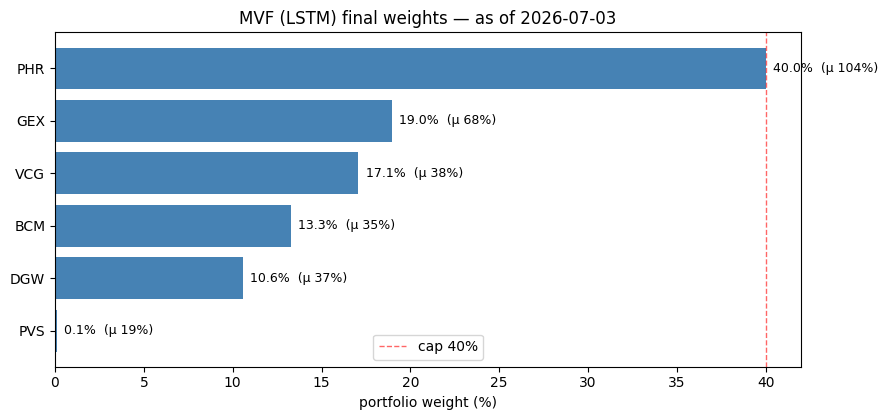

In [101]:
# ── Turn weights into an order sheet + visualise the allocation ──────────────
CAPITAL = 1_000_000_000     # capital to deploy (dataset price units × shares)

sheet = book.copy()
sheet['target_value'] = (w_final.reindex(sheet.index) * CAPITAL).round(0)
sheet['last_price']   = last_price.reindex(sheet.index)
sheet['shares']       = np.floor(sheet['target_value'] / sheet['last_price']).astype(int)
sheet['alloc_value']  = (sheet['shares'] * sheet['last_price']).round(0)

print(f'Order sheet for CAPITAL={CAPITAL:,.0f}  (as of {as_of.date()})')
display(sheet[['weight', 'last_price', 'shares', 'target_value', 'alloc_value']]
        .assign(weight=(w_final.reindex(sheet.index)*100).round(1).astype(str)+'%'))
print(f'Deployed: {sheet["alloc_value"].sum():,.0f}  |  '
      f'cash residual: {CAPITAL - sheet["alloc_value"].sum():,.0f}')

fig, ax = plt.subplots(figsize=(9, 0.55*len(book) + 1))
b = book.sort_values('weight')
ax.barh(b.index, b['weight']*100, color='steelblue')
for y, (w, mu) in enumerate(zip(b['weight']*100, b['pred_ann_return'])):
    ax.text(w + 0.4, y, f'{w:.1f}%  (μ {mu:.0%})', va='center', fontsize=9)
ax.axvline(MAX_WEIGHT*100, color='red', ls='--', lw=1, alpha=0.6, label=f'cap {MAX_WEIGHT:.0%}')
ax.set_xlabel('portfolio weight (%)')
ax.set_title(f'MVF (LSTM) final weights — as of {as_of.date()}')
ax.legend(); plt.tight_layout(); plt.show()